# CR3BP example

In [1]:
using Clarabel
using GLMakie
using JuMP
using LinearAlgebra
using OrdinaryDiffEq

In [2]:
include("../src/SCPLib.jl")

Main.SCPLib

In [22]:
Makie.inline!(true)   # for plotting within the notebook

true

In [3]:
mutable struct ControlParams
    μ::Float64
    u::Vector
    function ControlParams(μ::Float64)
        new(μ, zeros(4))
    end
end

μ = 1.215058560962404e-02
DU = 389703     # km
TU = 382981     # sec
MU = 500.0      # kg
VU = DU/TU      # km/s
params = ControlParams(μ)

function eom!(drv, rv, p, t)
    x, y, z = rv[1:3]
    vx, vy, vz = rv[4:6]
    r1 = sqrt( (x+p.μ)^2 + y^2 + z^2 );
    r2 = sqrt( (x-1+p.μ)^2 + y^2 + z^2 );
    drv[1:3] = rv[4:6]
    # derivatives of velocities
    drv[4] =  2*vy + x - ((1-p.μ)/r1^3)*(p.μ+x) + (p.μ/r2^3)*(1-p.μ-x);
    drv[5] = -2*vx + y - ((1-p.μ)/r1^3)*y - (p.μ/r2^3)*y;
    drv[6] = -((1-p.μ)/r1^3)*z - (p.μ/r2^3)*z;
    # append controls
    drv[4:6] += p.u[1:3]
    return
end


function eom_aug!(dx_aug, x_aug, p, t)
    # state derivatives
    eom!(view(dx_aug, 1:6), x_aug[1:6], p, t)
    
    # STM derivatives
    r1vec = [x_aug[1] + p.μ, x_aug[2], x_aug[3]]
    r2vec = [x_aug[1] - 1 + p.μ, x_aug[2], x_aug[3]]
    G1 = (1 - params.μ) / norm(r1vec)^5*(3*r1vec*r1vec' - norm(r1vec)^2*I(3))
    G2 = params.μ / norm(r2vec)^5*(3*r2vec*r2vec' - norm(r2vec)^2*I(3))
    Omega = [0 2 0; -2 0 0; 0 0 0]
    A = [zeros(3,3)                  I(3);
         G1 + G2 + diagm([1,1,0])    Omega]
    B = [zeros(3,4); I(3) zeros(3,1)]

    # derivatives of Phi_A, Phi_B
    dx_aug[7:42] = reshape((A * reshape(x_aug[7:42],6,6)), 36)
    dx_aug[nx*(nx+1)+1:nx*(nx+1)+nx*nu] = reshape((A * reshape(x_aug[nx*(nx+1)+1:nx*(nx+1)+nx*nu], (nx,nu)) + B), nx*nu)
end

eom_aug! (generic function with 1 method)

In [10]:
# initial & final LPO
rv0 = [1.0809931218390707E+00,
0.0000000000000000E+00,
-2.0235953267405354E-01,
1.0157158264396639E-14,
-1.9895001215078018E-01,
7.2218178975912707E-15]
period_0 = 2.3538670417546639E+00

rvf = [1.1648780946517576,
0.0,
-1.1145303634437023E-1,
0.0,
-2.0191923237095796E-1,
0.0]
period_f = 3.3031221822879884

sol_lpo0 = solve(
    ODEProblem(eom!, rv0, [0.0, period_0], params),
    Tsit5(); reltol = 1e-12, abstol = 1e-12
);
sol_lpof = solve(
    ODEProblem(eom!, rvf, [0.0, period_f], params),
    Tsit5(); reltol = 1e-12, abstol = 1e-12
);

In [11]:
function objective(x, u)
    return sum(u[4,:])
end

objective (generic function with 1 method)

### Continuous control problem

In [ ]:
# -------------------- create problem -------------------- #
N = 100
nx = 6
nu = 4                              # [ux,uy,uz,Γ]
tf = 2.6 
times = LinRange(0.0, tf, N)

thrust = 0.35    # N
umax = thrust/MU/1e3 / (VU/TU)

# initial & final LPO
sol_lpo0 = solve(
    ODEProblem(eom!, rv0, [0.0, period_0], params),
    Tsit5(); reltol = 1e-12, abstol = 1e-12
)
sol_lpof = solve(
    ODEProblem(eom!, rvf, [0.0, period_f], params),
    Tsit5(); reltol = 1e-12, abstol = 1e-12
)

# create reference solution
x_along_lpo0 = sol_lpo0(LinRange(0.0, period_0, N))
x_along_lpof = sol_lpof(LinRange(0.0, period_f, N))
x_ref = zeros(nx,N)
alphas = LinRange(0,1,N)
for (i,alpha) in enumerate(alphas)
    x_ref[:,i] = (1-alpha)*x_along_lpo0[:,i] + alpha*x_along_lpof[:,i]
end
u_ref = zeros(nu, N-1)

# plot initial guess
fig = Figure(size=(1200,800))
ax3d = Axis3(fig[1,1]; aspect=:data)
lines!(Array(sol_lpo0)[1,:], Array(sol_lpo0)[2,:], Array(sol_lpo0)[3,:], color=:blue)
lines!(Array(sol_lpof)[1,:], Array(sol_lpof)[2,:], Array(sol_lpof)[3,:], color=:green)

# instantiate problem object    
prob = SCPLib.ContinuousProblem(
    Clarabel.Optimizer,
    eom!,
    params,
    objective,
    times,
    x_ref,
    u_ref;
    # eom_aug! = eom_aug!,
    ode_method = Vern7(),
)
set_silent(prob.model)

# append boundary conditions
@constraint(prob.model, constraint_initial_rv, prob.model[:x][:,1] == rv0)
@constraint(prob.model, constraint_final_rv,   prob.model[:x][:,end] == rvf)

# append constraints on control magnitude
@constraint(prob.model, constraint_associate_control[k in 1:N-1],
    [prob.model[:u][4,k], prob.model[:u][1:3,k]...] in SecondOrderCone())
@constraint(prob.model, constraint_control_magnitude[k in 1:N-1],
    prob.model[:u][4,k] <= umax)


# -------------------- instantiate algorithm -------------------- #
algo = SCPLib.SCvxStar(nx, N; w0 = 1e4)

# solve problem
solution_continuous = SCPLib.solve!(algo, prob, x_ref, u_ref; maxiter = 100);

# propagate solution
sols_continuous, g_dynamics_opt = SCPLib.get_trajectory(prob, solution_continuous.x, solution_continuous.u)


 Solving OCP with SCvx* Algorithm (`・ω・´)

   Feasibility tolerance tol_feas :  1.00e-06
   Optimality tolerance tol_opt   :  1.00e-04
   Objective tolerance tol_J0     : -1.00e+16
   Initial penalty weight w       :  1.00e+04
   Use L1 penalty                 :  No
   Warmstart primal               :  No
   Warmstart dual                 :  No
   Use trust-region on u          :  No

Iter |     J0     |    ΔJ_i    |    ΔL_i    |     χ_i    |    ρ_i    |    r_i    |     w     |  acpt. |
   1 | -3.085e-10 |  5.319e+01 |  5.806e+01 |  1.043e-02 |  9.16e-01 |  5.00e-02 |  1.00e+04 |  yes   |
   2 |  1.724e-11 |  1.980e+01 |  2.430e+01 |  5.612e-03 |  8.15e-01 |  1.50e-01 |  2.00e+04 |  yes   |
   3 |  2.001e+00 | -6.762e+01 |  2.266e+01 |  2.469e-02 | -2.98e+00 |  4.50e-01 |  4.00e+04 |  no    |
   4 |  2.001e+00 | -6.762e+01 |  2.266e+01 |  2.469e-02 | -2.98e+00 |  2.25e-01 |  4.00e+04 |  no    |
   5 |  2.194e+00 |  1.125e+01 |  2.259e+01 |  8.513e-03 |  4.98e-01 |  1.13e-01 |  4.00e+0

(EnsembleSolution{Float64, 3, Vector{ODESolution{Float64, 2, Vector{Vector{Float64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Vector{Float64}}}, Nothing, ODEProblem{Vector{Float64}, Tuple{Float64, Float64}, true, ControlParams, ODEFunction{true, SciMLBase.AutoSpecialize, FunctionWrappersWrappers.FunctionWrappersWrapper{Tuple{FunctionWrappers.FunctionWrapper{Nothing, Tuple{Vector{Float64}, Vector{Float64}, ControlParams, Float64}}, FunctionWrappers.FunctionWrapper{Nothing, Tuple{Vector{ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}, Vector{ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}, ControlParams, Float64}}, FunctionWrappers.FunctionWrapper{Nothing, Tuple{Vector{ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}, Vector{Float64}, ControlParams, ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}}, FunctionWrappers.FunctionWrapper

### Impulsive control problem

In [19]:
function eom_impulsive!(drv, rv, p, t)
    x, y, z = rv[1:3]
    vx, vy, vz = rv[4:6]
    r1 = sqrt( (x+p.μ)^2 + y^2 + z^2 );
    r2 = sqrt( (x-1+p.μ)^2 + y^2 + z^2 );
    drv[1:3] = rv[4:6]
    # derivatives of velocities
    drv[4] =  2*vy + x - ((1-p.μ)/r1^3)*(p.μ+x) + (p.μ/r2^3)*(1-p.μ-x);
    drv[5] = -2*vx + y - ((1-p.μ)/r1^3)*y - (p.μ/r2^3)*y;
    drv[6] = -((1-p.μ)/r1^3)*z - (p.μ/r2^3)*z;
    return
end


function eom_impulsive_aug!(dx_aug, x_aug, p, t)
    x, y, z = x_aug[1:3]
    vx, vy, vz = x_aug[4:6]

    r1vec = [x + p.μ, y, z]
    r2vec = [x - 1 + p.μ, y, z]
    r1 = norm(r1vec)
    r2 = norm(r2vec)

    dx_aug[1:3] = x_aug[4:6]
    # derivatives of velocities
    dx_aug[4] =  2*vy + x - ((1-p.μ)/r1^3)*(p.μ+x) + (p.μ/r2^3)*(1-p.μ-x);
    dx_aug[5] = -2*vx + y - ((1-p.μ)/r1^3)*y - (p.μ/r2^3)*y;
    dx_aug[6] = -((1-p.μ)/r1^3)*z - (p.μ/r2^3)*z;
    
    # Jacobian derivatives
    G1 = (1 - p.μ) / norm(r1vec)^5*(3*r1vec*r1vec' - norm(r1vec)^2*I(3))
    G2 = p.μ / norm(r2vec)^5*(3*r2vec*r2vec' - norm(r2vec)^2*I(3))
    Omega = [0 2 0; -2 0 0; 0 0 0]
    A = [zeros(3,3)                  I(3);
        G1 + G2 + diagm([1,1,0])    Omega]

    # derivatives of Phi_A, Phi_B
    dx_aug[7:42] = reshape((A * reshape(x_aug[7:42],6,6)), 36)
end

eom_impulsive_aug! (generic function with 1 method)

In [20]:
# -------------------- create problem -------------------- #
N = 100
nx = 6
nu = 4                              # [ux,uy,uz,Γ]
tf = 2.6 
times = LinRange(0.0, tf, N)

thrust = 0.35    # N
umax = thrust/MU/1e3 / (VU/TU)

# create reference solution
x_along_lpo0 = sol_lpo0(LinRange(0.0, period_0, N))
x_along_lpof = sol_lpof(LinRange(0.0, period_f, N))
x_ref = zeros(nx,N)
alphas = LinRange(0,1,N)
for (i,alpha) in enumerate(alphas)
    x_ref[:,i] = (1-alpha)*x_along_lpo0[:,i] + alpha*x_along_lpof[:,i]
end
u_ref = zeros(nu, N)

# instantiate problem object    
prob = SCPLib.ImpulsiveProblem(
    Clarabel.Optimizer,
    eom_impulsive!,
    params,
    objective,
    times,
    x_ref,
    u_ref;
    eom_aug! = eom_impulsive_aug!,
    ode_method = Vern7(),
)
set_silent(prob.model)

# append boundary conditions
@constraint(prob.model, constraint_initial_rv, prob.model[:x][:,1] == rv0)
@constraint(prob.model, constraint_final_r,    prob.model[:x][1:3,end] == rvf[1:3])
@constraint(prob.model, constraint_final_v,    prob.model[:x][4:6,end] + prob.model[:u][1:3,end] == rvf[4:6])

# append constraints on control magnitude
@constraint(prob.model, constraint_associate_control[k in 1:N],
    [prob.model[:u][4,k], prob.model[:u][1:3,k]...] in SecondOrderCone())
@constraint(prob.model, constraint_control_magnitude[k in 1:N],
    prob.model[:u][4,k] <= umax)

# -------------------- instantiate algorithm -------------------- #
Δ0 = [0.05, 0.05, 0.05, 0.1, 0.1, 0.1]
algo = SCPLib.SCvxStar(nx, N; w0 = 1e4, Δ0 = Δ0, l1_penalty = true)

# solve problem
tol_opt = 1e-6
tol_feas = 1e-8
solution_impulsive = SCPLib.solve!(algo, prob, x_ref, u_ref;
    verbosity = 1, maxiter = 100, tol_opt = tol_opt, tol_feas = tol_feas)

# propagate solution
sols_impulsive, g_dynamics_opt = SCPLib.get_trajectory(prob, solution_impulsive.x, solution_impulsive.u)


 Solving OCP with SCvx* Algorithm (`・ω・´)

   Feasibility tolerance tol_feas :  1.00e-08
   Optimality tolerance tol_opt   :  1.00e-06
   Objective tolerance tol_J0     : -1.00e+16
   Initial penalty weight w       :  1.00e+04
   Use L1 penalty                 :  Yes
   Warmstart primal               :  No
   Warmstart dual                 :  No
   Use trust-region on u          :  No

Iter |     J0     |    ΔJ_i    |    ΔL_i    |     χ_i    |    ρ_i    |    r_i    |     w     |  acpt. |
   1 |  2.756e-01 |  1.125e+02 |  1.703e+02 |  1.748e-02 |  6.60e-01 |  5.00e-02 |  1.00e+04 |  yes   |
   2 |  2.251e-01 |  1.034e+02 |  1.241e+02 |  2.595e-03 |  8.33e-01 |  5.00e-02 |  2.00e+04 |  yes   |
   3 |  2.152e-01 |  2.458e+01 |  3.352e+01 |  1.643e-03 |  7.33e-01 |  1.50e-01 |  4.00e+04 |  yes   |
   4 |  2.137e-01 |  1.158e+01 |  1.445e+01 |  5.074e-04 |  8.01e-01 |  4.50e-01 |  8.00e+04 |  yes   |
   5 |  2.134e-01 |  2.309e+00 |  4.167e+00 |  2.575e-04 |  5.54e-01 |  1.35e+00 |  1.60e+

(EnsembleSolution{Float64, 3, Vector{ODESolution{Float64, 2, Vector{Vector{Float64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Vector{Float64}}}, Nothing, ODEProblem{Vector{Float64}, Tuple{Float64, Float64}, true, ControlParams, ODEFunction{true, SciMLBase.AutoSpecialize, FunctionWrappersWrappers.FunctionWrappersWrapper{Tuple{FunctionWrappers.FunctionWrapper{Nothing, Tuple{Vector{Float64}, Vector{Float64}, ControlParams, Float64}}, FunctionWrappers.FunctionWrapper{Nothing, Tuple{Vector{ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}, Vector{ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}, ControlParams, Float64}}, FunctionWrappers.FunctionWrapper{Nothing, Tuple{Vector{ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}, Vector{Float64}, ControlParams, ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}}, FunctionWrappers.FunctionWrapper

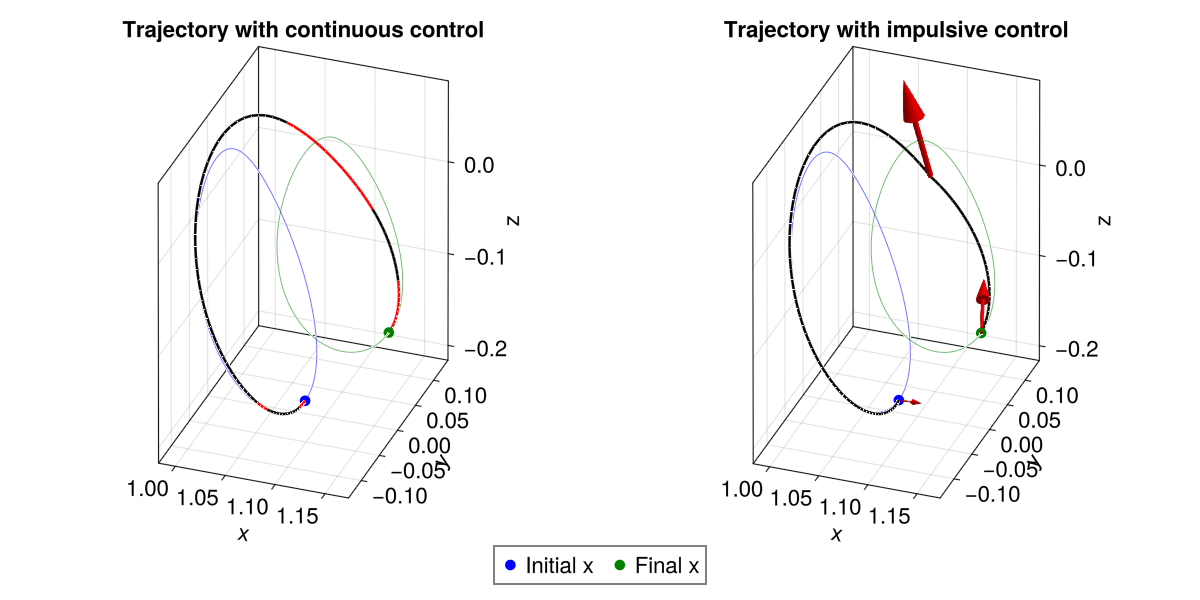

GLMakie.Screen(...)

In [108]:
fontsize = 22

fig = Figure(size=(1200,600))
ax3d = Axis3(fig[1,1]; aspect=:data, xlabel="x", ylabel="y", zlabel="z", azimuth=deg2rad(290), elevation=deg2rad(30),
    title="Trajectory with continuous control",
    titlesize = fontsize,
    xlabelsize = fontsize, ylabelsize = fontsize, zlabelsize = fontsize,
    xticklabelsize = fontsize, yticklabelsize = fontsize, zticklabelsize = fontsize)
arc_colors = [solution_continuous.u[4,i] > 1e-6 ? :red : :black for i in 1:N-1]
for (isol, _sol) in enumerate(sols_continuous)
    lines!(ax3d, Array(_sol)[1,:], Array(_sol)[2,:], Array(_sol)[3,:], color=arc_colors[isol], linewidth=2.5)
end
lines!(ax3d, Array(sol_lpo0)[1,:], Array(sol_lpo0)[2,:], Array(sol_lpo0)[3,:], color=:blue, linewidth=0.5)
lines!(ax3d, Array(sol_lpof)[1,:], Array(sol_lpof)[2,:], Array(sol_lpof)[3,:], color=:green, linewidth=0.5)
scatter!(ax3d, [sol_lpo0[1,1]], [sol_lpo0[2,1]], [sol_lpo0[3,1]], color=:blue, markersize=15, label="Initial x")
scatter!(ax3d, [sol_lpof[1,end]], [sol_lpof[2,end]], [sol_lpof[3,end]], color=:green, markersize=15, label="Final x")


ax3d = Axis3(fig[1,2]; aspect=:data, xlabel="x", ylabel="y", zlabel="z", azimuth=deg2rad(290), elevation=deg2rad(30),
    title="Trajectory with impulsive control",
    titlesize = fontsize,
    xlabelsize = fontsize, ylabelsize = fontsize, zlabelsize = fontsize,
    xticklabelsize = fontsize, yticklabelsize = fontsize, zticklabelsize = fontsize)
for (isol, _sol) in enumerate(sols_impulsive)
    lines!(ax3d, Array(_sol)[1,:], Array(_sol)[2,:], Array(_sol)[3,:], color=:black, linewidth=2.5)
end
arrows3d!(ax3d,
    solution_impulsive.x[1,:], solution_impulsive.x[2,:], solution_impulsive.x[3,:],
    solution_impulsive.u[1,:], solution_impulsive.u[2,:], solution_impulsive.u[3,:],
    color=:red, shaftradius=0.025, tipradius=0.1, lengthscale=1.0)
lines!(ax3d, Array(sol_lpo0)[1,:], Array(sol_lpo0)[2,:], Array(sol_lpo0)[3,:], color=:blue, linewidth=0.5)
lines!(ax3d, Array(sol_lpof)[1,:], Array(sol_lpof)[2,:], Array(sol_lpof)[3,:], color=:green, linewidth=0.5)
scatter!(ax3d, [sol_lpo0[1,1]], [sol_lpo0[2,1]], [sol_lpo0[3,1]], color=:blue, markersize=15, label="Initial x")
scatter!(ax3d, [sol_lpof[1,end]], [sol_lpof[2,end]], [sol_lpof[3,end]], color=:green, markersize=15, label="Final x")

Legend(fig[2,1:2], ax3d, orientation=:horizontal, labelsize = fontsize)

save("plots/cr3bp_transfer_continuous_impulsive.png", fig; px_per_unit = 5)
display(fig)
